#  **Deep Neural Networks for Image Classification (Part II)**
#  **Convolutional Neural Networks (CNNs)**

We will create Convolutional Neural Networks (CNNs) for classifying **MNIST** and **CIFAR10** images using PyTorch library, as in the previous lab.
* **MNIST** dataset contains 70,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9.
* **CIFAR10** dataset contains 60,000 32x32 RGB images divided into 10 classes of animals/vehicles (plane, car, bird, cat, deer, dog, frog, horse, ship, truck)

**Use the GPU** to speed up the training time of you models (Runtime -> Change runtime type -> Hardware accelerator -> GPU).

 More details on **PyTorch** at https://pytorch.org/ - https://pytorch.org/tutorials/.  

## **MLP/CNN Contest: useful links**

*   [Submit results](https://docs.google.com/forms/d/e/1FAIpQLSeuBPHemQ1L-8KW1azUWhDklUOlBfXBn_Ihh4oThUBb7rR-Zg/viewform)
*   [Ranking Visualization](https://docs.google.com/spreadsheets/d/1jaoCqJ2KzMqVUlUAYhAAIyDeWYNwwlzD5Rkyz0YR3hI/edit?usp=sharing)

In [ ]:
# Pytorch functions
import torch
# Neural network layers
import torch.nn as nn
import torch.nn.functional as F
# Optimizer
import torch.optim as optim
# Handling dataset
import torch.utils.data as data
# Torchvision library
import torchvision

import matplotlib.pyplot as plt
import random
import numpy as np
import copy
import time
import os
import cv2
# For results
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

*  Set "USE_SEED" to False for your own experiments.

In [ ]:
def set_seed(seed, use_gpu = True):
    """
    Set SEED for PyTorch reproducibility
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if use_gpu:
        torch.cuda.manual_seed_all(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 44

USE_SEED = True

if USE_SEED:
    set_seed(SEED, torch.cuda.is_available())

## **How to create Convolutional and Max-Pooling layers**
Let's see how to create max-pooling and convolutional layers using PyTorch.

  *  torch.nn.MaxPool2d(kernel_size, stride=None, padding=0, dilation=1, return_indices=False, ceil_mode=False)
  *  torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros')


In [ ]:
# Define a "fake" image
image = torch.randn((1, 1, 28, 28)) # [batch_size, n_channels, height, width]
print(f"Image size: {image.shape}")

Image size: torch.Size([1, 1, 28, 28])


In [ ]:
max_pool = nn.MaxPool2d(kernel_size = 2)
img_max_pool = max_pool(image)

print(f"2D Max Pooling Output size: {img_max_pool.shape}")

2D Max Pooling Output size: torch.Size([1, 1, 14, 14])


In [ ]:
# In pytorch out channels is the number of filters :)
conv_2d = nn.Conv2d(in_channels = 1, out_channels = 64, kernel_size = 3)
img_conv_2d = conv_2d(image)

print(f"2D Conv Output size: {img_conv_2d.shape}")
# Batch size 1, 64 filters maps of size 26x26

2D Conv Output size: torch.Size([1, 64, 26, 26])


**Remember: $d_{out} = \frac{d_{in} - d_{kernel} + 2 \cdot pad}{stride}+1$**


Therefore, if $d_{in} = 28$, $d_{kernel} = 3$, $stride = 1$, $pad=0$:

$d_{out} = \frac{28-3+2 \cdot 0}{1}+1 = 26$

In [ ]:
print(conv_2d.weight.data.shape)
# Select first filter
print(conv_2d.weight.data[0][0])

torch.Size([64, 1, 3, 3])
tensor([[ 0.3050,  0.0840, -0.2269],
        [-0.2799,  0.2433,  0.1699],
        [-0.0929, -0.3318, -0.1995]])


In [ ]:
# We can also define our own kernel
f = torch.FloatTensor([[0, 0, 0],
                  [0, 1, 0],
                  [0, 0, 0]]) # Identity kernel

conv_2d.weight.data[0][0] = f

print(conv_2d.weight.data[0][0])

tensor([[0., 0., 0.],
        [0., 1., 0.],
        [0., 0., 0.]])


##**MNIST image classfication**

In [ ]:
# Load MNIST dataset
# Available datasets at https://pytorch.org/vision/stable/datasets.html
ROOT = './data'
train_data = torchvision.datasets.MNIST(root=ROOT, train=True, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.04MB/s]


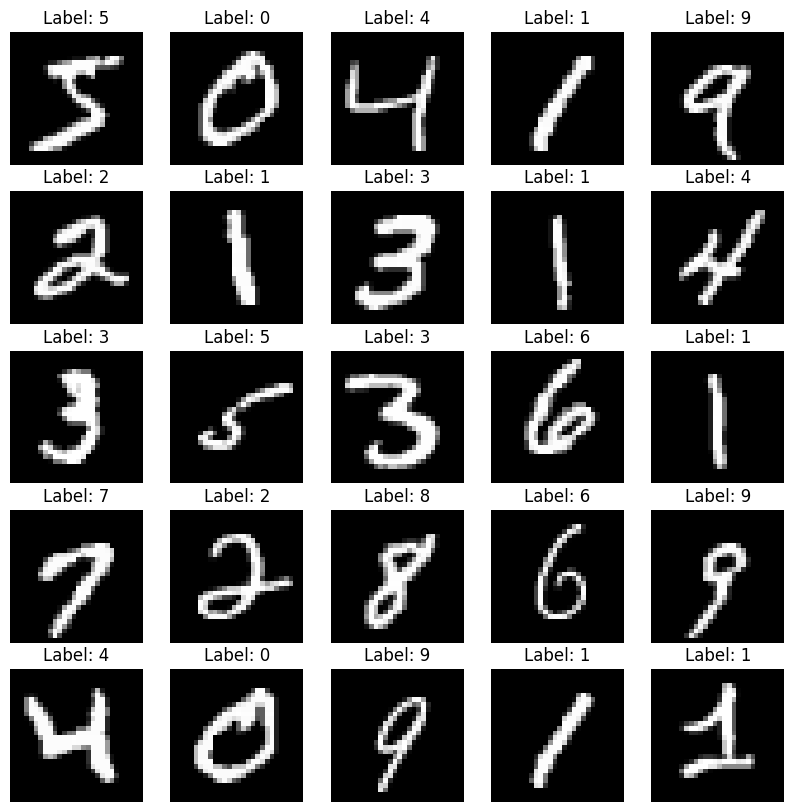

In [ ]:
# Plot some training images
N_IMAGES = 25
plt.figure(figsize=(10, 10))
for i in range(N_IMAGES):
  img = train_data.data[i] # Unnormalized images
  label = train_data[i][1]
  plt.subplot(5,5,i+1), plt.imshow(img, cmap='gray'), plt.title(f"Label: {label}"), plt.axis('off')

In [ ]:
# Select 1st image
min_px_value = train_data.data[0].min()
print(f"Minimum pixel value : {min_px_value}")
max_px_value = train_data.data[0].max()
print(f"Maximum pixel value : {max_px_value}")

Minimum pixel value : 0
Maximum pixel value : 255


In [ ]:
# Data normalization
# Mean and std should be divided by 255 (maximum pixel value)
# because, after the ToTensor() transformation (see next step), images are normalized
# between 0 and 1.

train_mean = train_data.data.float().mean() / 255
train_std = train_data.data.float().std() / 255

print("-----  TRAIN NORMALIZATION VALUES  -----")
print(f"Mean: {train_mean:.4f}")
print(f"Standard Deviation: {train_std:.4f}")

-----  TRAIN NORMALIZATION VALUES  -----
Mean: 0.1307
Standard Deviation: 0.3081


In [ ]:
# Compositions of transformations
train_transforms = torchvision.transforms.Compose([
                                                   torchvision.transforms.ToTensor(),
                                                   torchvision.transforms.Normalize(train_mean, train_std) # values are normalized between 0 and 1
])

test_transforms = torchvision.transforms.Compose([
                                                  torchvision.transforms.ToTensor(),
                                                  torchvision.transforms.Normalize(train_mean, train_std) # values are normalized between 0 and 1
])

In [ ]:
# Load data with transformations
train_data = torchvision.datasets.MNIST(root=ROOT,
                                        train=True,
                                        download=True,
                                        transform=train_transforms)

test_data = torchvision.datasets.MNIST(root=ROOT,
                                        train=False,
                                        download=True,
                                        transform=test_transforms)
print(train_data)
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.13066047430038452, std=0.30810779333114624)
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.13066047430038452, std=0.30810779333114624)
           )


In [ ]:
def create_validation_set(train_data, train_percentage, test_transforms):

  # Split train data into train and validation sets
  # (10% of training set will be used as validation set)
  num_train_examples = int(len(train_data) * train_percentage)
  num_valid_examples = len(train_data) - num_train_examples

  # Create 'Subset' objects
  train_data, valid_data = data.random_split(train_data, [num_train_examples, num_valid_examples])

  print(f"Number training examples: {len(train_data)}")
  print(f"Number validation examples: {len(valid_data)}")

  # Apply test transformations to the validation set
  valid_data = copy.deepcopy(valid_data) # If we change train transformations, this won't affect the validation set
  valid_data.dataset.transform = test_transforms

  return valid_data

In [ ]:
valid_data = create_validation_set(train_data, 0.8, test_transforms)

Number training examples: 48000
Number validation examples: 12000


In [ ]:
# Create iterators
BATCH_SIZE = 64

train_iterator = torch.utils.data.DataLoader(train_data,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE)

valid_iterator = torch.utils.data.DataLoader(valid_data,
                                             batch_size=BATCH_SIZE)

test_iterator = torch.utils.data.DataLoader(test_data,
                                            batch_size=BATCH_SIZE)

**Ex.1**

Implement a LeNet-like architecture to classify handwritten digits. Compared to the original architecture, we will use **28x28** (instead of 32x32) input images and standard linear layers (we will not consider Gaussian connections).

	• INPUT: 28x28 grayscale image;
	• LAYER 1: Convolutional layer with 6 convolutional filters (select a padding value such that the output is a 28x28 feature map);
	• LAYER 2: A max pooling layer that down-samples Layer 1. Pass the output of Layer 2 through a ReLU activation function;
	• LAYER 3: Convolutional layer with 16 convolutional filters;
	• LAYER 4: A max pooling layer that down-samples Layer 3. Pass the output of Layer 4 through a ReLU activation function;
	• FLATTEN: Flatten the image to put it through linear layers;
	• LAYER 5: Linear layer (ouput dim = 120). Pass the output of Layer 5 through a ReLU activation function;
	• LAYER 6: Linear layer (ouput dim = 84). Pass the output of Layer 6 through a ReLU activation function;
	• LAYER 7: Linear layer (ouput dim = 10)

You can infer the kernel size of each convolutional layer from the image below.

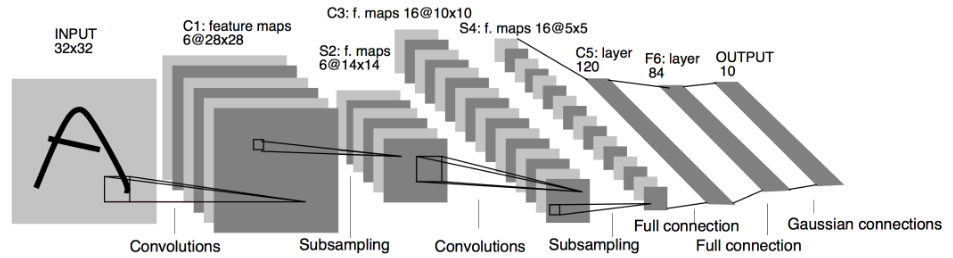

**Ex. 1.1** - Compute the number of parameters for each layer of the previous network.

**Remember: $d_{out} = \frac{d_{in} - d_{kernel} + 2 \cdot pad}{stride}+1$**


Therefore, if $d_{in} = 28$, $d_{kernel} = 3$, $stride = 1$, $pad=0$:

$d_{out} = \frac{28-3+2 \cdot 0}{1}+1 = 26$

In [ ]:
class LeNet(nn.Module):
  def __init__(self, output_dim):
    super().__init__()
    self.features = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2),
    nn.MaxPool2d(kernel_size=2),
    nn.ReLU(),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
    nn.MaxPool2d(kernel_size=2),
    nn.ReLU()
    )
    self.linear = nn.Sequential(
    nn.Linear(16 * 5 * 5, 120),
    nn.ReLU(),
    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Linear(84, output_dim)
    )
  def forward(self, x):
    x = self.features(x)
    x = x.view(x.shape[0], -1)
    x = self.linear(x)
    return x

In [ ]:
OUTPUT_DIM = 10
model = LeNet(OUTPUT_DIM)

In [ ]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The model has {count_parameters(model):,} trainable parameters.")

The model has 61,706 trainable parameters.


In [ ]:
# Loss
criterion = nn.CrossEntropyLoss() # Softmax + CrossEntropy

# Put model&criterion on GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = criterion.to(device)

In [ ]:
# Optim
optimizer = optim.Adam(model.parameters(), lr=1e-4)

model = model.to(device)

* Training phase

In [ ]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  # Train mode
  model.train()

  for (x,y) in iterator:
    x = x.to(device)
    y = y.to(device)
    # Set gradients to zero
    optimizer.zero_grad()

    # Make Predictions
    y_pred = model(x)

    # Compute loss
    loss = criterion(y_pred, y)

    # Compute accuracy
    acc = calculate_accuracy(y_pred, y)

    # Backprop
    loss.backward()

    # Apply optimizer
    optimizer.step()

    # Extract data from loss and accuracy
    epoch_loss += loss.item()
    epoch_acc += acc.item()

  return epoch_loss/len(iterator), epoch_acc/len(iterator)

* Validation/Testing phase

In [ ]:
def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  # Evaluation mode
  model.eval()

  # Do not compute gradients
  with torch.no_grad():

    for(x,y) in iterator:

      x = x.to(device)
      y = y.to(device)

      # Make Predictions
      y_pred = model(x)

      # Compute loss
      loss = criterion(y_pred, y)

      # Compute accuracy
      acc = calculate_accuracy(y_pred, y)

      # Extract data from loss and accuracy
      epoch_loss += loss.item()
      epoch_acc += acc.item()

  return epoch_loss/len(iterator), epoch_acc/len(iterator)

In [ ]:
def calculate_accuracy(y_pred, y):
  '''
  Compute accuracy from ground-truth and predicted labels.

  Input
  ------
  y_pred: torch.Tensor [BATCH_SIZE, N_LABELS]
  y: torch.Tensor [BATCH_SIZE]

  Output
  ------
  acc: float
    Accuracy
  '''
  y_prob = F.softmax(y_pred, dim = -1)
  y_pred = y_pred.argmax(dim=1, keepdim = True)
  correct = y_pred.eq(y.view_as(y_pred)).sum()
  acc = correct.float()/y.shape[0]
  return acc

In [ ]:
def model_training(n_epochs, model, train_iterator, valid_iterator, optimizer, criterion, device, model_name='best_model.pt'):

  # Initialize validation loss
  best_valid_loss = float('inf')

  # Save output losses, accs
  train_losses = []
  train_accs = []
  valid_losses = []
  valid_accs = []

  # Loop over epochs
  for epoch in range(n_epochs):
    start_time = time.time()
    # Train
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    # Validation
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)
    # Save best model
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      # Save model
      torch.save(model.state_dict(), model_name)
    end_time = time.time()

    print(f"\nEpoch: {epoch+1}/{n_epochs} -- Epoch Time: {end_time-start_time:.2f} s")
    print("---------------------------------")
    print(f"Train -- Loss: {train_loss:.3f}, Acc: {train_acc * 100:.2f}%")
    print(f"Val -- Loss: {valid_loss:.3f}, Acc: {valid_acc * 100:.2f}%")

    # Save
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

  return train_losses, train_accs, valid_losses, valid_accs

In [ ]:
N_EPOCHS = 30
#train_losses, train_accs, valid_losses, valid_accs = model_training(N_EPOCHS,
#                                                                    model,
#                                                                    train_iterator,
#                                                                    valid_iterator,
#                                                                    optimizer,
#                                                                    criterion,
#                                                                    device,
#                                                                    'lenet.pt')

In [ ]:
def plot_results(n_epochs, train_losses, train_accs, valid_losses, valid_accs):
  N_EPOCHS = n_epochs
  # Plot results
  plt.figure(figsize=(20, 6))
  _ = plt.subplot(1,2,1)
  plt.plot(np.arange(N_EPOCHS)+1, train_losses, linewidth=3)
  plt.plot(np.arange(N_EPOCHS)+1, valid_losses, linewidth=3)
  _ = plt.legend(['Train', 'Validation'])
  plt.grid('on'), plt.xlabel('Epoch'), plt.ylabel('Loss')

  _ = plt.subplot(1,2,2)
  plt.plot(np.arange(N_EPOCHS)+1, train_accs, linewidth=3)
  plt.plot(np.arange(N_EPOCHS)+1, valid_accs, linewidth=3)
  _ = plt.legend(['Train', 'Validation'])
  plt.grid('on'), plt.xlabel('Epoch'), plt.ylabel('Accuracy')

In [ ]:
#plot_results(N_EPOCHS, train_losses, train_accs, valid_losses, valid_accs)

In [ ]:
def model_testing(model, test_iterator, criterion, device, model_name='best_model.pt'):
  # Test model
  model.load_state_dict(torch.load(model_name))
  test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
  print(f"Test -- Loss: {test_loss:.3f}, Acc: {test_acc * 100:.2f} %")

In [ ]:
#model_testing(model, test_iterator, criterion, device, 'lenet.pt')

In [ ]:
def predict(model, iterator, device):

  # Evaluation mode
  model.eval()

  labels = []
  pred = []

  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred = model(x)

      # Get label with highest score
      y_prob = F.softmax(y_pred, dim = -1)
      top_pred = y_prob.argmax(1, keepdim=True)

      labels.append(y.cpu())
      pred.append(top_pred.cpu())

  labels = torch.cat(labels, dim=0)
  pred = torch.cat(pred, dim=0)

  return labels, pred


In [ ]:
def print_report(model, test_iterator, device):
  labels, pred = predict(model, test_iterator, device)
  print(confusion_matrix(labels, pred))
  print("\n")
  print(classification_report(labels, pred))

In [ ]:
#print_report(model, test_iterator, device)

### **Feature Maps Visualization**

We will now visualize some filters and feature maps, selecting the first 5 test images and the first CONV layer.

CONV1 LAYER: torch.Size([6, 1, 5, 5])
in_channels: 1, out_channels: 6, kernel_size: 5


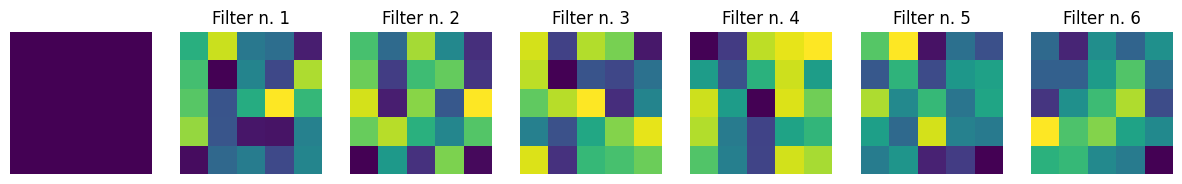

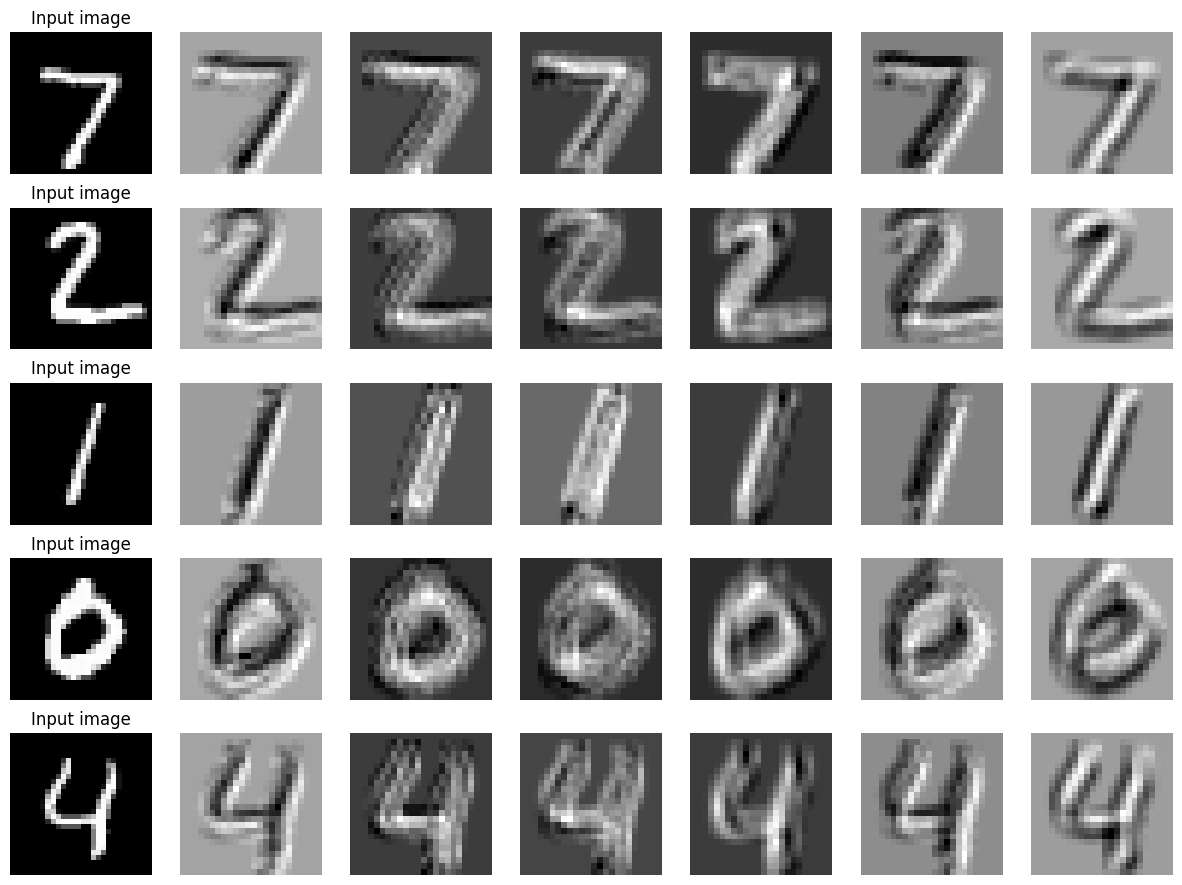

In [ ]:
N_IMAGES = 5

# Get filters
filters = model.features[0].weight.data

# Parameters
in_channels = filters.shape[1]
out_channels = filters.shape[0]
kernel_size = filters.shape[2]
print(f"CONV1 LAYER: {filters.shape}\nin_channels: {in_channels}, out_channels: {out_channels}, kernel_size: {kernel_size}")

fig = plt.figure(figsize=(15,10))
for i in range(filters.shape[0]):
  if i == 0:
    plt.subplot(1, 7, i+1), plt.imshow(torch.zeros(filters.size(2), filters.size(3)).cpu()), plt.axis('off')
  image = filters[i][0]
  # image.clamp_(min = image.min(), max = image.max())
  # image.add_(-image.min()).div_(image.max() - image.min() + 1e-5)
  plt.subplot(1, 7, i+2), plt.imshow(image.cpu()), plt.title(f"Filter n. {i+1}")
  plt.axis('off')

# Select images
images = [image for image, label in [test_data[i] for i in range(N_IMAGES)]]

# # Define 2d filter
filter_2d = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size).to(device)
filter_2d.weight.data = filters

N_FILTERS = out_channels
fig = plt.figure(figsize=(15,11))
for i in range(N_IMAGES):
  # Plot image
  image = images[i]
  image = image[None, ...]
  plt.subplot(5, N_FILTERS+1, i+1 + (N_FILTERS*i)), plt.imshow(image[0][0].cpu(), cmap = 'gray'), plt.axis('off')
  plt.title('Input image')

  # Plot filtered image
  filtered_image = filter_2d(image.to(device))
  for f in range(N_FILTERS):
    fil_image = filtered_image[0][f]
    plt.subplot(5, N_FILTERS+1, f+2 + ((N_FILTERS+1)*i)), plt.imshow(fil_image.cpu().detach().numpy(), cmap = 'gray'), plt.axis('off')

##**CIFAR10 image classification**
*  Load CIFAR10 dataset;
*  Import **VGG16 architecure**;
*  Train VGG16 on CIFAR10 **from scratch** or using a VGG-16 **pre-trained** on ImageNet.

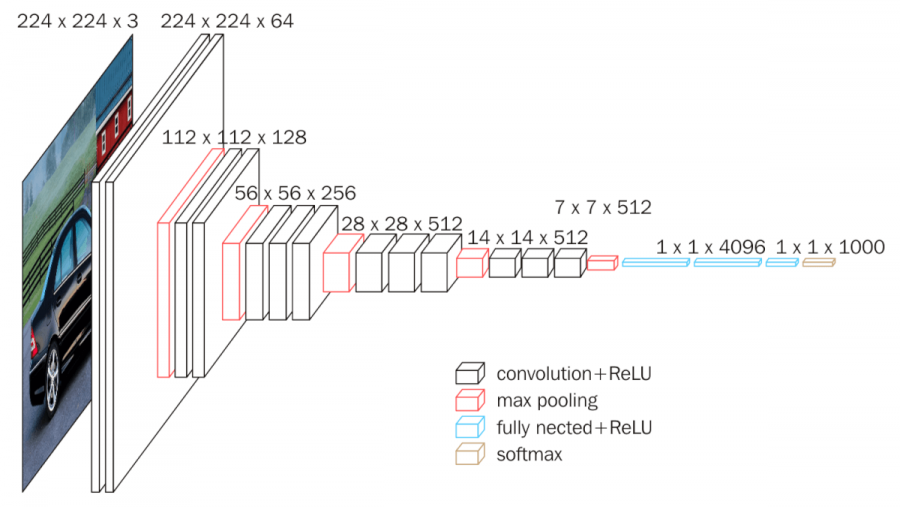

In [ ]:
# Load CIFAR10 dataset
# Available datasets at https://pytorch.org/vision/stable/datasets.html
ROOT = './data'
train_data = torchvision.datasets.CIFAR10(root=ROOT, train=True, download=True)

# You can also use the 'transform' argument to specify transformations to apply to the dataset
# e.g. 'train_data = torchvision.datasets.CIFAR10(root=ROOT, train=True, download=True, transform=...)'
# See the next steps for applying transformations to a dataset.

100%|██████████| 170M/170M [00:16<00:00, 10.3MB/s]


In [ ]:
# -----  TRAIN NORMALIZATION VALUES  -----
# Refer to the previous lab to compute mean and std.
train_mean =  [0.49139968, 0.48215841, 0.44653091]
train_std = [0.24703223, 0.24348513, 0.26158784]

*   We will use 32x32 pixel as image size instead of 224x224 to speed up the training time. You can also try to add the resize transformation.

In [ ]:
# Compositions of transformations
train_transforms = torchvision.transforms.Compose([
                                                  #torchvision.transforms.Resize((224,224)),
                                                   torchvision.transforms.ToTensor(), # values are normalized between 0 and 1
                                                   torchvision.transforms.Normalize(train_mean, train_std)
])

test_transforms = torchvision.transforms.Compose([
                                                 #torchvision.transforms.Resize((224,224)),
                                                  torchvision.transforms.ToTensor(),
                                                  torchvision.transforms.Normalize(train_mean, train_std)
])

In [ ]:
# Load data with transformations
train_data = torchvision.datasets.CIFAR10(root=ROOT,
                                        train=True,
                                        download=True,
                                        transform=train_transforms)

test_data = torchvision.datasets.CIFAR10(root=ROOT,
                                        train=False,
                                        download=True,
                                        transform=test_transforms)
print(train_data)
print(test_data)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.49139968, 0.48215841, 0.44653091], std=[0.24703223, 0.24348513, 0.26158784])
           )
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.49139968, 0.48215841, 0.44653091], std=[0.24703223, 0.24348513, 0.26158784])
           )


In [ ]:
valid_data = create_validation_set(train_data, 0.8, test_transforms)

Number training examples: 40000
Number validation examples: 10000


In [ ]:
# Create iterators
BATCH_SIZE = 128

train_iterator = torch.utils.data.DataLoader(train_data,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE)

valid_iterator = torch.utils.data.DataLoader(valid_data,
                                             batch_size=BATCH_SIZE)

test_iterator = torch.utils.data.DataLoader(test_data,
                                            batch_size=BATCH_SIZE)

**Load VGG16 architecture**

In [ ]:
%%capture
vgg16 = torchvision.models.vgg16(pretrained = False)

In [ ]:
print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Let's **modify the 'classifier' section** of the VGG16 network since our dataset contains **10 classes**.

In [ ]:
print(vgg16.classifier[-1])
print(f"Input features: {vgg16.classifier[-1].in_features}")
print(f"Output features: {vgg16.classifier[-1].out_features}")

Linear(in_features=4096, out_features=1000, bias=True)
Input features: 4096
Output features: 1000


In [ ]:
print(f'The model has {count_parameters(vgg16):,} trainable parameters')

The model has 138,357,544 trainable parameters


In [ ]:
for p in vgg16.classifier[-1].parameters():
  print(p.shape)

torch.Size([1000, 4096])
torch.Size([1000])


In [ ]:
OUTPUT_DIM = 10
vgg16.classifier[-1] = nn.Linear(vgg16.classifier[-1].in_features, OUTPUT_DIM)

In [ ]:
print(vgg16.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=10, bias=True)
)


In [ ]:
print(f'The model has {count_parameters(vgg16):,} trainable parameters')

The model has 134,301,514 trainable parameters


In [ ]:
for p in vgg16.classifier[-1].parameters():
  print(p.shape)

torch.Size([10, 4096])
torch.Size([10])


In [ ]:
# Optim
optimizer = optim.Adam(vgg16.parameters(), lr=1e-5)

vgg16 = vgg16.to(device)

In [ ]:
N_EPOCHS = 30
#train_losses_vgg16_scratch, train_accs_vgg16_scratch, valid_losses_vgg16_scratch, valid_accs_vgg16_scratch = model_training(N_EPOCHS,
#                                                                                                                            vgg16,
#                                                                                                                            train_iterator,
#                                                                                                                            valid_iterator,
#                                                                                                                            optimizer,
#                                                                                                                            criterion,
#                                                                                                                            device,
#                                                                                                                            'vgg16.pt')

In [ ]:
#plot_results(N_EPOCHS, train_losses_vgg16_scratch, train_accs_vgg16_scratch, valid_losses_vgg16_scratch, valid_accs_vgg16_scratch)

In [ ]:
#model_testing(vgg16, test_iterator, criterion, device, 'vgg16.pt')

In [ ]:
#print_report(vgg16, test_iterator, device)

### **Transfer Learning**


*  Finetuning
*  Feature extraction

In finetuning, we use a pretrained model and update all of its parameters for the new task (**the whole model is retrained**). In feature extraction, we use a pretrained model and only update the final layer(s) weights. In this case, we use a pretrained CNN as a **fixed** feature-extractor, and only change its output layer(s).

Steps for both transfer learning methods:

*  Initialize a pretrained model;
*  Reshape the final layer(s) to match number of outputs and number of classes in the new dataset;
*  Define which parameters must be updated during training;
*  Train the network.

*  Data normalization

From the PyTorch website (https://pytorch.org/vision/stable/models.html):

> All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of **shape (3 x H x W)**, where **H and W** are expected to be **at least 224**. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

In [ ]:
# Normalize CIFAR10
mean_imagenet = [0.485, 0.456, 0.406]
std_imagenet = [0.229, 0.224, 0.225]

In [ ]:
# Compositions of transformations
train_transforms = torchvision.transforms.Compose([
                                                    #torchvision.transforms.Resize((224,224)),
                                                    torchvision.transforms.RandomHorizontalFlip(),
                                                    torchvision.transforms.ToTensor(), # values are normalized between 0 and 1
                                                    torchvision.transforms.Normalize(mean_imagenet, std_imagenet)
])

test_transforms = torchvision.transforms.Compose([
                                                    #torchvision.transforms.Resize((224,224)),
                                                    torchvision.transforms.ToTensor(),
                                                    torchvision.transforms.Normalize(mean_imagenet, std_imagenet)
])

In [ ]:
# Load data with transformations
train_data = torchvision.datasets.CIFAR10(root=ROOT,
                                        train=True,
                                        download=True,
                                        transform=train_transforms)

test_data = torchvision.datasets.CIFAR10(root=ROOT,
                                        train=False,
                                        download=True,
                                        transform=test_transforms)
print(train_data)
print(test_data)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [ ]:
valid_data = create_validation_set(train_data, 0.8, test_transforms)

Number training examples: 40000
Number validation examples: 10000


In [ ]:
# Create iterators
BATCH_SIZE = 128

train_iterator = torch.utils.data.DataLoader(train_data,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE)

valid_iterator = torch.utils.data.DataLoader(valid_data,
                                             batch_size=BATCH_SIZE)

test_iterator = torch.utils.data.DataLoader(test_data,
                                            batch_size=BATCH_SIZE)

#### **1. Finetuning**

In [ ]:
%%capture
vgg16_fine_tuning = torchvision.models.vgg16(pretrained = True) # Load weights

In [ ]:
print(vgg16_fine_tuning.classifier[-1])

Linear(in_features=4096, out_features=1000, bias=True)


In [ ]:
# Define new output layer
OUTPUT_DIM = 10
vgg16_fine_tuning.classifier[-1] = nn.Linear(vgg16_fine_tuning.classifier[-1].in_features, OUTPUT_DIM)

In [ ]:
# Optim
optimizer = optim.Adam(vgg16_fine_tuning.parameters(), lr=1e-5)

vgg16_fine_tuning = vgg16_fine_tuning.to(device)

In [ ]:
N_EPOCHS = 30
#train_losses_vgg16_fine_tuning, train_accs_vgg16_fine_tuning, valid_losses_vgg16_fine_tuning, valid_accs_vgg16_fine_tuning = model_training(N_EPOCHS,
#                                                                                                                            vgg16_fine_tuning,
#                                                                                                                            train_iterator,
#                                                                                                                            valid_iterator,
#                                                                                                                            optimizer,
#                                                                                                                            criterion,
#                                                                                                                            device,
#                                                                                                                            'vgg16_fine_tuning.pt')

In [ ]:
#plot_results(N_EPOCHS, train_losses_vgg16_fine_tuning, train_accs_vgg16_fine_tuning, valid_losses_vgg16_fine_tuning, valid_accs_vgg16_fine_tuning)

In [ ]:
#model_testing(vgg16_fine_tuning, test_iterator, criterion, device, 'vgg16_fine_tuning.pt')

In [ ]:
#print_report(vgg16_fine_tuning, test_iterator, device)

####**2. Feature extraction**


In [ ]:
%%capture
vgg16_feat_extract = torchvision.models.vgg16(pretrained = True) # Load weights

In [ ]:
OUTPUT_DIM = 10
vgg16_feat_extract.classifier[-1] = nn.Linear(vgg16_feat_extract.classifier[-1].in_features, OUTPUT_DIM)

In [ ]:
# Freeze all "features" layers
for parameter in vgg16_feat_extract.features.parameters():
  parameter.requires_grad = False
# Uncomment the following line to freeze all the "classifier" layers but the last FC layer
# for parameter in vgg16_feat_extract.classifier[:-1].parameters():
#   parameter.requires_grad = False

In [ ]:
# Optim
optimizer = optim.SGD(vgg16_feat_extract.parameters(), lr=1e-3)

vgg16_feat_extract = vgg16_feat_extract.to(device)

In [ ]:
N_EPOCHS = 30
#train_losses_vgg16_feat_extract, train_accs_vgg16_feat_extract, valid_losses_vgg16_feat_extract, valid_accs_vgg16_feat_extract = model_training(N_EPOCHS,
#                                                                                                                            vgg16_feat_extract,
#                                                                                                                            train_iterator,
#                                                                                                                            valid_iterator,
#                                                                                                                            optimizer,
#                                                                                                                            criterion,
#                                                                                                                            device,
#                                                                                                                            'vgg16_feat_extract.pt')

In [ ]:
#plot_results(N_EPOCHS, train_losses_vgg16_feat_extract, train_accs_vgg16_feat_extract, valid_losses_vgg16_feat_extract, valid_accs_vgg16_feat_extract)

In [ ]:
#model_testing(vgg16_feat_extract, test_iterator, criterion, device, 'vgg16_feat_extract.pt')

In [ ]:
#print_report(vgg16_feat_extract, test_iterator, device)

#### **Performances recap**

Accuracies:
* train from scratch: 64.51 %
* finetuning: 87.43 %
* feature extraction: 67.03%

In [ ]:
#model_testing(vgg16, test_iterator, criterion, device, 'vgg16.pt') # train from scratch
#model_testing(vgg16_fine_tuning, test_iterator, criterion, device, 'vgg16_fine_tuning.pt') # finetuning
#model_testing(vgg16_feat_extract, test_iterator, criterion, device, 'vgg16_feat_extract.pt') # feature extraction

# **CNN Contest**

Previous networks do not perform well on CIFAR-10 dataset.
**Design your own architecture** and set the corresponding hyper-parameters in order to achieve better performance on the test set. Some parameters to focus on are listed below:

#### *Network's parameters*:

- Number of layers;
- Number of neurons per layer;
- Activation functions;
- Weights initialization;
- Dropout Rate.

#### *Training parameters*:
- Learning rate;
- Number of epochs;
- Optimizer;
- Batch size.

#### *Data*:
- Data augmentation.

You can also use different training techniques (e.g., early stopping, LR schedule) or consider ensemble methods.

#### *Pre-trained networks*:
- Use different pre-trained networks.

### 0. Deep CNN From Scratch

In [ ]:
LEARNING_RATE = 1e-5
BATCH_SIZE=64
N_EPOCHS = 100
OUTPUT_DIM = 10

In [ ]:
## Define the CNN model
class AdvancedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AdvancedCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32 * 2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32 * 2, out_channels=64 * 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64 * 2, out_channels=64 * 2, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=64 * 2, out_channels=128 * 2, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=128 * 2, out_channels=128 * 2, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(in_channels=128 * 2, out_channels=128 * 2, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(in_channels=128 * 2, out_channels=256 * 2, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(in_channels=256 * 2, out_channels=256 * 2, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(in_channels=256 * 2, out_channels=256 * 2, kernel_size=3, padding=1)

        self.bn1 = nn.BatchNorm2d(32 * 2)
        self.bn2 = nn.BatchNorm2d(128 * 2)
        self.bn3 = nn.BatchNorm2d(256 * 2)

        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout2d(0.2)

        self.fc1 = nn.Linear(4096 * 2, 4096 * 2)
        self.fc2 = nn.Linear(4096 * 2, 2048 * 2)
        self.fc3 = nn.Linear(2048 * 2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.maxpool(x)

        x = self.relu(self.bn2(self.conv4(x)))
        x = self.relu(self.conv5(x))
        x = self.relu(self.conv6(x))
        x = self.maxpool(x)
        x = self.dropout(x)

        x = self.relu(self.bn3(self.conv7(x)))
        x = self.relu(self.conv8(x))
        x = self.relu(self.conv9(x))
        x = self.maxpool(x)
        x = self.dropout(x)

        x = torch.flatten(x, start_dim=1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


# Instantiating the network and printing its architecture
num_classes = 10
net = AdvancedCNN(num_classes)
net = net.to(device)
optimizer = optim.Adam(vgg16_fine_tuning.parameters(), lr=LEARNING_RATE)
train_losses_CNN, train_accs_CNN, valid_losses_CNN, valid_accs_CNN = model_training(                         N_EPOCHS,
                                                                                                                            net,
                                                                                                                            train_iterator,
                                                                                                                            valid_iterator,
                                                                                                                            optimizer,
                                                                                                                            criterion,
                                                                                                                            device,
                                                                                                                            'advanced_CNN.pt')

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:1531: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)



Epoch: 1/100 -- Epoch Time: 61.93 s
---------------------------------
Train -- Loss: 2.303, Acc: 9.67%
Val -- Loss: 2.303, Acc: 8.96%

Epoch: 2/100 -- Epoch Time: 64.61 s
---------------------------------
Train -- Loss: 2.303, Acc: 9.59%
Val -- Loss: 2.303, Acc: 9.01%

Epoch: 3/100 -- Epoch Time: 64.55 s
---------------------------------
Train -- Loss: 2.303, Acc: 9.68%
Val -- Loss: 2.303, Acc: 8.99%

Epoch: 4/100 -- Epoch Time: 60.80 s
---------------------------------
Train -- Loss: 2.303, Acc: 9.64%
Val -- Loss: 2.303, Acc: 9.07%

Epoch: 5/100 -- Epoch Time: 61.01 s
---------------------------------
Train -- Loss: 2.303, Acc: 9.71%
Val -- Loss: 2.303, Acc: 8.95%

Epoch: 6/100 -- Epoch Time: 60.66 s
---------------------------------
Train -- Loss: 2.303, Acc: 9.53%
Val -- Loss: 2.303, Acc: 9.06%


KeyboardInterrupt: 

## 1. VGG19

In [ ]:
LEARNING_RATE = 1e-4
BATCH_SIZE=64
N_EPOCHS = 100
OUTPUT_DIM = 10

### Feature Extraction (Head fine-tuning)

In [ ]:
import torchvision.models as models

# Load the pretrained VGG19 with Batch Normalization
# 'pretrained=True' loads weights trained on the ImageNet dataset
model = models.vgg19_bn(weights=models.VGG19_BN_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[-1].in_features # Get input size of the original last layer

# Replace the last Linear layer with a new one for 10 classes
# We keep the original structure of the classifier head for consistency
new_classifier = nn.Sequential(
    *model.classifier[:-1],  # Keep all layers except the last one
    nn.Linear(in_features, OUTPUT_DIM)
)

model.classifier = new_classifier
print(f"Total Parameters (VGG19_BN): {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters (for CIFAR-10): {count_parameters(model):,}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses_VGG19, train_accs_VGG19, valid_losses_VGG19, valid_accs_VGG19 = model_training(N_EPOCHS,
                                                                                    model,
                                                                                    train_iterator,
                                                                                    valid_iterator,
                                                                                    optimizer,
                                                                                    criterion,
                                                                                    device,
                                                                                    'vgg19_finetune_frozen.pt')

### Full Fine-tuning

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch

# Load the pretrained VGG19 with Batch Normalizationx
# 'pretrained=True' loads weights trained on the ImageNet dataset
model = models.vgg19_bn(weights=models.VGG19_BN_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = True
in_features = model.classifier[-1].in_features # Get input size of the original last layer

# Replace the last Linear layer with a new one for 10 classes
# We keep the original structure of the classifier head for consistency
new_classifier = nn.Sequential(
    *model.classifier[:-1],  # Keep all layers except the last one
    nn.Linear(in_features, OUTPUT_DIM)
)

model.classifier = new_classifier
print(f"Total Parameters (VGG19_BN): {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters (for CIFAR-10): {count_parameters(model):,}")
# NOTE: The trainable count should now equal the Total Parameters count!

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses_VGG19_full, train_accs_VGG19_full, valid_losses_VGG19_full, valid_accs_VGG19_full = model_training(N_EPOCHS,
                                                                                    model,
                                                                                    train_iterator,
                                                                                    valid_iterator,
                                                                                    optimizer,
                                                                                    criterion,
                                                                                    device,
                                                                                    'vgg19_finetune_full.pt')

In [ ]:
print_report(model, test_iterator, device)
#plot_results(N_EPOCHS, train_losses_VGG19_full, train_accs_VGG19_full, valid_losses_VGG19_full, valid_accs_VGG19_full)
model_testing(model, test_iterator, criterion, device, 'vgg19_finetune_full.pt')


### RESULTS:

22 iterations overfitted and got a 85% in test, probably could get more if we stopped in iterations 10-13 with FULL FINETUNING

## 2. Swin2 Vision Transfomer (ViT)

In [ ]:
LEARNING_RATE = 1e-4
BATCH_SIZE=64
N_EPOCHS = 100
OUTPUT_DIM = 10

In [ ]:
from transformers import AutoModelForImageClassification

def load_hf_model(model_id, output_dim, strategy='feature_extraction'):
    model = AutoModelForImageClassification.from_pretrained(model_id)

    # Adapt the classification head ('classifier' or 'head' in HF models)
    if hasattr(model, 'classifier'):
        in_features = model.config.hidden_size
        model.classifier = nn.Linear(in_features, output_dim)
    # Note: If using ViT, the head might be 'head'. The code handles this via config.hidden_size.

    # Apply Feature Extraction strategy (Frozen)
    if strategy == 'feature_extraction':
        for param in model.parameters():
            param.requires_grad = False
        # Ensure the new head is trainable
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model

In [ ]:
MODEL_ID = 'microsoft/swinv2-large-patch4-window12-192-22k'
model = load_hf_model(
    model_id=MODEL_ID,
    output_dim=OUTPUT_DIM,
    strategy='feature_extraction'
)

# The model is already frozen, and the head is replaced.
print(f"Total Parameters ({MODEL_ID}): {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters (for CIFAR-10): {count_parameters(model):,}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training execution remains the same
train_losses_SWVIT, train_accs_SWVIT, valid_losses_SWVIT, valid_accs_SWVIT = model_training(N_EPOCHS,
                                                                                    model,
                                                                                    train_iterator,
                                                                                    valid_iterator,
                                                                                    optimizer,
                                                                                    criterion,
                                                                                    device,
                                                                                    'swinv2_finetuning_frozen.pt')

In [ ]:
print_report(model, test_iterator, device)
plot_results(N_EPOCHS, train_losses_SWVIT, train_accs_SWVIT, valid_losses_SWVIT, valid_accs_SWVIT)
model_testing(model, test_iterator, criterion, device, 'swinv2_finetuning_frozenpt')


### Full Fine-Tuning

## 3. ConvNeXt

## 4. EfficientNetV2

## 5. Inception V3

## 6. CLIP

## 7. DaViT

## 8. ViT

In [ ]:
model

In [ ]:
import torchvision.transforms as transforms
import torchvision.models as models
# 1. Get the official preprocessing transforms for the specific weights
weights = models.ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1
data_transforms = weights.transforms()

# 2. You must apply these transforms to your datasets
# Assuming you loaded your CIFAR10 dataset as 'train_data' and 'test_data'
# and assuming you have a way to apply the transforms to them:

# Apply the standard inference transforms (Resize(518), CenterCrop(518), Normalize)
# to your validation/test data.
test_data.transform = data_transforms

# For training data, it's highly recommended to use the standard transforms,
# but you might want to replace the CenterCrop with a RandomCrop for augmentation.
# The core is the Resize and Normalize components!

# Example of an Augmented Training Transform (replace if you have a custom one):
train_transforms = transforms.Compose([
    transforms.Resize(518, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(518),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
train_data.transform = train_transforms

# You must now re-initialize your DataLoaders:
# train_iterator = torch.utils.data.DataLoader(train_data, batch_size=..., shuffle=True)
# valid_iterator = torch.utils.data.DataLoader(test_data, batch_size=...)

model = models.vit_h_14(weights=models.ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1)

for param in model.parameters():
    param.requires_grad = True

in_features = model.heads.head.in_features

model.heads.head = nn.Linear(in_features, OUTPUT_DIM)

print(f"Total Parameters (ViT-H/14): {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters (for CIFAR-10): {count_parameters(model):,}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses_VIT_full, train_accs_VIT_full, valid_losses_VIT_full, valid_accs_VIT_full = model_training(N_EPOCHS,
                                                                                    model,
                                                                                    train_iterator,
                                                                                    valid_iterator,
                                                                                    optimizer,
                                                                                    criterion,
                                                                                    device,
                                                                                    'vit_h_finetune_full.pt')

Downloading: "https://download.pytorch.org/models/vit_h_14_swag-80465313.pth" to /root/.cache/torch/hub/checkpoints/vit_h_14_swag-80465313.pth


100%|██████████| 2.36G/2.36G [00:54<00:00, 46.4MB/s]


Total Parameters (ViT-H/14): 632,202,250
Trainable Parameters (for CIFAR-10): 632,202,250


OutOfMemoryError: CUDA out of memory. Tried to allocate 858.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 226.12 MiB is free. Process 6308 has 14.52 GiB memory in use. Of the allocated memory 13.48 GiB is allocated by PyTorch, and 922.43 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
print_report(model, test_iterator, device)
plot_results(N_EPOCHS, train_losses_VIT_full, train_accs_VIT_full, valid_losses_VIT_full, valid_accs_VIT_full)
model_testing(model, test_iterator, criterion, device, 'vit_h_finetune_full.pt')
